# Run with TabPFN environment

In [1]:
!which python

/work/dlclarge1/hoos-time/miniforge3/envs/time-dev/bin/python


# Preparation

## Dataset

In [2]:
# Read all dataset configs from point_forecast.yaml
import yaml

POINT_FORECAST_CONFIG = "resources/benchmarks/point_forecast.yaml"

with open(POINT_FORECAST_CONFIG) as file:
    raw_config = yaml.load(file, Loader=yaml.FullLoader)

config = {}
for c in raw_config:
    config[c["name"]] = c

config.keys()

dict_keys(['car_parts', 'cif_2016', 'covid_deaths', 'electricity_hourly', 'electricity_weekly', 'fred_md', 'hospital', 'kdd_cup_2018', 'm1_monthly', 'm1_quarterly', 'm1_yearly', 'm3_monthly', 'm3_other', 'm3_quarterly', 'm3_yearly', 'm4_daily', 'm4_hourly', 'm4_monthly', 'm4_quarterly', 'm4_weekly', 'm4_yearly', 'nn5_daily', 'nn5_weekly', 'pedestrian_counts', 'tourism_monthly', 'tourism_quarterly', 'tourism_yearly', 'vehicle_trips', 'web_traffic_weekly'])

In [3]:
selected_dataset = [
    "cif_2016",
    # "m4_hourly",
    # "tourism_yearly",
    # "vehicle_trips",
]

# assert all selected datasets are in the config
for d in selected_dataset:
    assert d in config, f"{d} not in config"

In [4]:
# Load all datasets
from tqdm import tqdm
from amlb.datasets.file import TimeSeriesDataset
from amlb.utils.core import Namespace
from frameworks.shared.utils import load_timeseries_dataset
from concurrent.futures import ThreadPoolExecutor, as_completed

from tabpfn_ts.data import TimeSeriesDataFrame

datasets = {}

def fetch_dataset(dataset_config: dict[str, any]):
    name = dataset_config["name"]
    d_config = dataset_config["dataset"]
    print(f"Loading {name}")

    dataset = TimeSeriesDataset(
        path=d_config["path"],
        fold=0,
        target=d_config["target"],
        features="timestamp",
        cache_dir="./tmp_cache",
        config=Namespace(d_config | {"name": name}),
    )

    dataset.train_path = dataset.train.path
    dataset.test_path = dataset.test.path

    train_df, test_df = load_timeseries_dataset(dataset)
    train_tsdf = TimeSeriesDataFrame(
        train_df,
        id_column=dataset.id_column,
        timestamp_column=dataset.timestamp_column
    )
    test_tsdf = TimeSeriesDataFrame(
        test_df,
        id_column=dataset.id_column,
        timestamp_column=dataset.timestamp_column
    )

    print(f"Loading {name} done.")
    return name, {"train": train_tsdf, "test": test_tsdf}


with ThreadPoolExecutor(max_workers=4) as executor:
    futures = [executor.submit(fetch_dataset, config[d]) for d in selected_dataset]
    for future in tqdm(as_completed(futures), total=len(selected_dataset)):
        name, dataset = future.result()
        datasets[name] = dataset

/work/dlclarge1/hoos-time/miniforge3/envs/time-dev/lib/python3.10/site-packages/_distutils_hack/__init__.py:26: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")


Loading cif_2016


  0%|                                                                                                                                                                                                                        | 0/1 [00:00<?, ?it/s]/work/dlclarge1/hoos-time/playground/automlbenchmark/amlb/datasets/file.py:459: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  features = [Feature(i, col, to_feature_type(dtypes[i])) for i, col in enumerate(self._ds.columns)]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.38it/s]

Loading cif_2016 done.


In [5]:
# Examine the datasets
for d, val in datasets.items():
    print(f"{d}: {val['train'].shape} {val['test'].shape}")

cif_2016: (6244, 1) (864, 1)


## Utils (data preprocessing, evaluation etc.)

In [8]:
from tabpfn_ts.data import TimeSeriesDataFrame
from tabpfn_ts.pipeline import PredictionPipeline

pred_pipeline_config_file = "/home/hoos/hoos-time/playground/tabpfn-time-series/tabpfn_ts/pipeline/config/sin_cos_range_gpu.json"
pipeline = PredictionPipeline.from_config_file(pred_pipeline_config_file)
pipeline.predictor.debug = True

train_tsdf = datasets["cif_2016"]["train"]
test_tsdf = datasets["cif_2016"]["test"]

# Select a subset of data
indices = train_tsdf.item_ids[:5]
train_tsdf = train_tsdf.loc[indices]
test_tsdf = test_tsdf.loc[indices]

prediction_length = 12
pred_train = True

pred = pipeline.predict(
    train_tsdf=train_tsdf,
    predict_length=prediction_length,
    quantile_config=[0.1, 0.9],
    predict_train=pred_train,
)



  0%|                                                                                                                                                                                                                        | 0/5 [00:00<?, ?it/s]

debug, TabPFNRegressor train_X
             counter     sin_1     cos_1     sin_2     cos_2     sin_3  \
timestamp                                                               
1970-01-31        0  0.000000  1.000000  0.000000  1.000000  0.000000   
1970-02-28        1  0.841471  0.540302  0.479426  0.877583  0.327195   
1970-03-31        2  0.909297 -0.416147  0.841471  0.540302  0.618370   
1970-04-30        3  0.141120 -0.989992  0.997495  0.070737  0.841471   
1970-05-31        4 -0.756802 -0.653644  0.909297 -0.416147  0.971938   

               cos_3     sin_4     cos_4     sin_5  ...    sin_20    cos_20  \
timestamp                                           ...                       
1970-01-31  1.000000  0.000000  1.000000  0.000000  ...  0.000000  1.000000   
1970-02-28  0.944957  0.247404  0.968912  0.198669  ...  0.049979  0.998750   
1970-03-31  0.785887  0.479426  0.877583  0.389418  ...  0.099833  0.995004   
1970-04-30  0.540302  0.681639  0.731689  0.564642  ...  0.14

 20%|█████████████████████████████████████████▌                                                                                                                                                                      | 1/5 [00:04<00:16,  4.12s/it]

debug, TabPFNRegressor train_X
             counter     sin_1     cos_1     sin_2     cos_2     sin_3  \
timestamp                                                               
1970-01-31        0  0.000000  1.000000  0.000000  1.000000  0.000000   
1970-02-28        1  0.841471  0.540302  0.479426  0.877583  0.327195   
1970-03-31        2  0.909297 -0.416147  0.841471  0.540302  0.618370   
1970-04-30        3  0.141120 -0.989992  0.997495  0.070737  0.841471   
1970-05-31        4 -0.756802 -0.653644  0.909297 -0.416147  0.971938   

               cos_3     sin_4     cos_4     sin_5  ...    sin_20    cos_20  \
timestamp                                           ...                       
1970-01-31  1.000000  0.000000  1.000000  0.000000  ...  0.000000  1.000000   
1970-02-28  0.944957  0.247404  0.968912  0.198669  ...  0.049979  0.998750   
1970-03-31  0.785887  0.479426  0.877583  0.389418  ...  0.099833  0.995004   
1970-04-30  0.540302  0.681639  0.731689  0.564642  ...  0.14

 40%|███████████████████████████████████████████████████████████████████████████████████▏                                                                                                                            | 2/5 [00:08<00:12,  4.09s/it]

...

 60%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                                                   | 3/5 [00:12<00:08,  4.08s/it]

debug, TabPFNRegressor train_X
             counter     sin_1     cos_1     sin_2     cos_2     sin_3  \
timestamp                                                               
1970-01-31        0  0.000000  1.000000  0.000000  1.000000  0.000000   
1970-02-28        1  0.841471  0.540302  0.479426  0.877583  0.327195   
1970-03-31        2  0.909297 -0.416147  0.841471  0.540302  0.618370   
1970-04-30        3  0.141120 -0.989992  0.997495  0.070737  0.841471   
1970-05-31        4 -0.756802 -0.653644  0.909297 -0.416147  0.971938   

               cos_3     sin_4     cos_4     sin_5  ...    sin_20    cos_20  \
timestamp                                           ...                       
1970-01-31  1.000000  0.000000  1.000000  0.000000  ...  0.000000  1.000000   
1970-02-28  0.944957  0.247404  0.968912  0.198669  ...  0.049979  0.998750   
1970-03-31  0.785887  0.479426  0.877583  0.389418  ...  0.099833  0.995004   
1970-04-30  0.540302  0.681639  0.731689  0.564642  ...  0.14

 80%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍                                         | 4/5 [00:16<00:04,  4.07s/it]

debug, TabPFNRegressor train_X
             counter     sin_1     cos_1     sin_2     cos_2     sin_3  \
timestamp                                                               
1970-01-31        0  0.000000  1.000000  0.000000  1.000000  0.000000   
1970-02-28        1  0.841471  0.540302  0.479426  0.877583  0.327195   
1970-03-31        2  0.909297 -0.416147  0.841471  0.540302  0.618370   
1970-04-30        3  0.141120 -0.989992  0.997495  0.070737  0.841471   
1970-05-31        4 -0.756802 -0.653644  0.909297 -0.416147  0.971938   

               cos_3     sin_4     cos_4     sin_5  ...    sin_20    cos_20  \
timestamp                                           ...                       
1970-01-31  1.000000  0.000000  1.000000  0.000000  ...  0.000000  1.000000   
1970-02-28  0.944957  0.247404  0.968912  0.198669  ...  0.049979  0.998750   
1970-03-31  0.785887  0.479426  0.877583  0.389418  ...  0.099833  0.995004   
1970-04-30  0.540302  0.681639  0.731689  0.564642  ...  0.14

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:20<00:00,  4.08s/it]


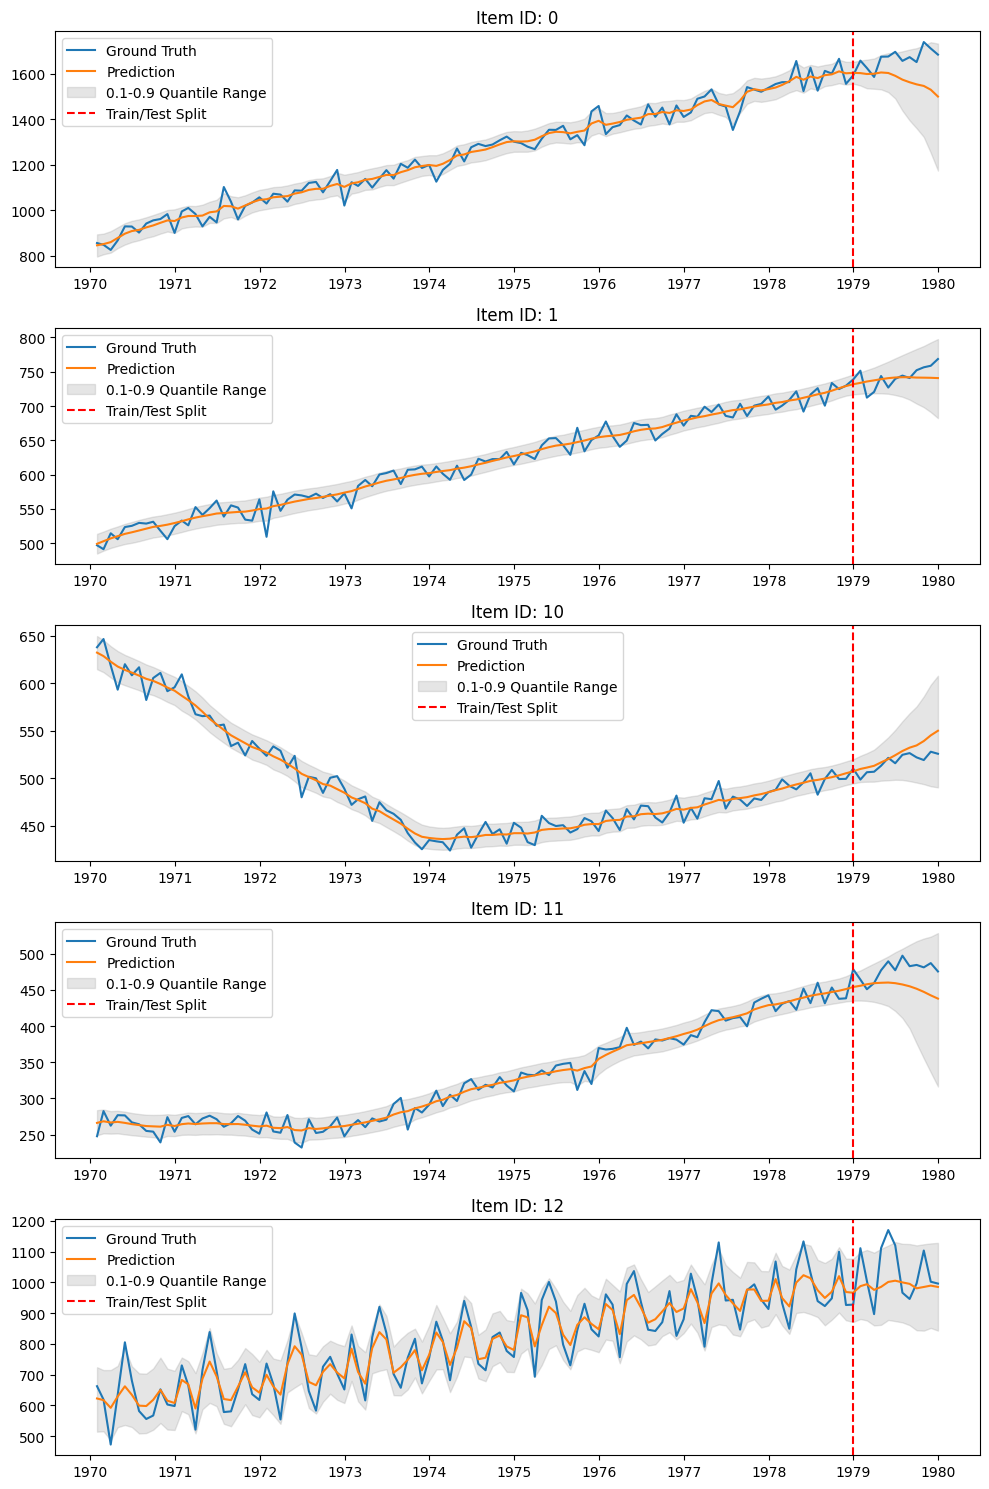

In [9]:
import pandas as pd
from tabpfn_ts.data.utils import plot_pred_and_actual_ts

ground_truth_tsdf = test_tsdf if not pred_train else pd.concat([train_tsdf, test_tsdf])

plot_pred_and_actual_ts(
    pred=pred,
    train=train_tsdf,
    test=ground_truth_tsdf
)